# 2. Evaluate — original CRM data (`data/crm/`)

Same steps as `python -m src.evaluate --output reports/crm/final`, using the functions in `src/evaluate.py`.
Loads the models saved by `1_train.ipynb`; nothing here can change the selected model, threshold or calibration.

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "train.py").is_file())
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src import evaluate, train
from src.data.crm import CRM_DIR


## Settings

Must match the settings used in `1_train.ipynb`.

In [2]:
DATA_DIR = CRM_DIR   # real Maven CRM tables
QUICK = False            # True: tiny budgets, smoke test only (writes a *smoke* folder)
OUTPUT = train.default_output(DATA_DIR, QUICK)
print("Data:  ", DATA_DIR)
print("Output:", OUTPUT)

Data:   /Users/thaiphan/sources/miu/cs582-project/data/crm
Output: /Users/thaiphan/sources/miu/cs582-project/reports/crm/final


## 1. Load the saved models and rebuild the same split

In [3]:
ev = evaluate.start(OUTPUT)
print("Data:", ev.out.source_data())
print("Selected model:", ev.trained.selected, "| mode:", ev.manifest["mode"])
print("Test deals:", len(ev.split.test))

Data: /Users/thaiphan/sources/miu/cs582-project/data/crm
Selected model: logistic_regression | mode: full
Test deals: 1361


## 2. Test metrics

Each model uses its own validation threshold. The Dummy control shows what predicting the majority class gives.

In [4]:
COLUMNS = ["model", "roc_auc", "accuracy", "balanced_accuracy", "precision", "recall", "f1", "brier", "tn", "fp", "fn", "tp"]
evaluate.score_test(ev)[COLUMNS].round(4)

,model,roc_auc,accuracy,balanced_accuracy,precision,recall,f1,brier,tn,fp,fn,tp
0,dummy_prior,0.5000,0.6003,0.5000,0.6003,1.0000,0.7502,0.2421,0,544,0,817
1,logistic_regression,0.5238,0.4372,0.5051,0.6154,0.1665,0.2620,0.2794,459,85,681,136
2,random_forest,0.5180,0.5922,0.4954,0.5981,0.9780,0.7422,0.2510,7,537,18,799
3,mlp,0.4954,0.4849,0.4930,0.5929,0.4529,0.5135,0.3314,290,254,447,370
4,tabnet,0.5068,0.5356,0.4999,0.6002,0.6781,0.6368,0.2490,175,369,263,554


### Calibration of the selected model

Calibration changes the probability scale (Brier), not the ranking (ROC-AUC).

In [5]:
pd.read_csv(ev.out.metrics / "calibration_test.csv")[["variant", "roc_auc", "brier", "log_loss", "accuracy", "f1", "threshold"]].round(4)

,variant,roc_auc,brier,log_loss,accuracy,f1,threshold
0,raw,0.5238,0.2794,0.7541,0.4372,0.262,0.4800
1,calibrated,0.5238,0.2443,0.6818,0.4372,0.262,0.6044


## 3. Figures

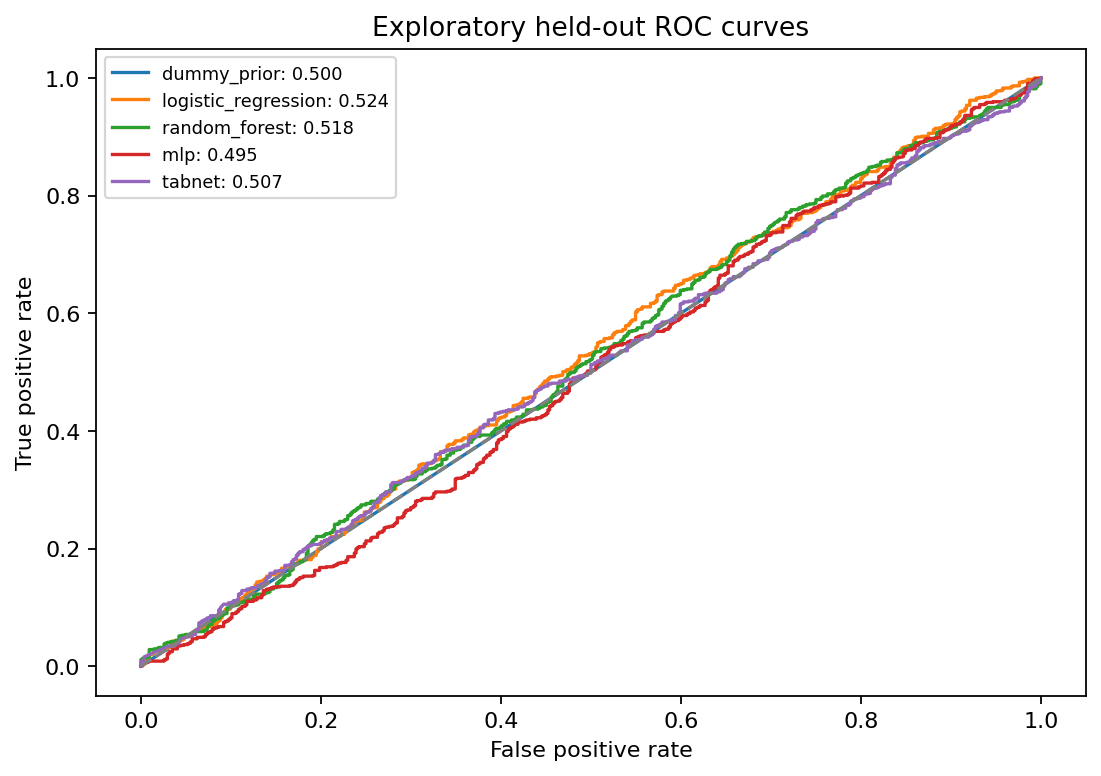

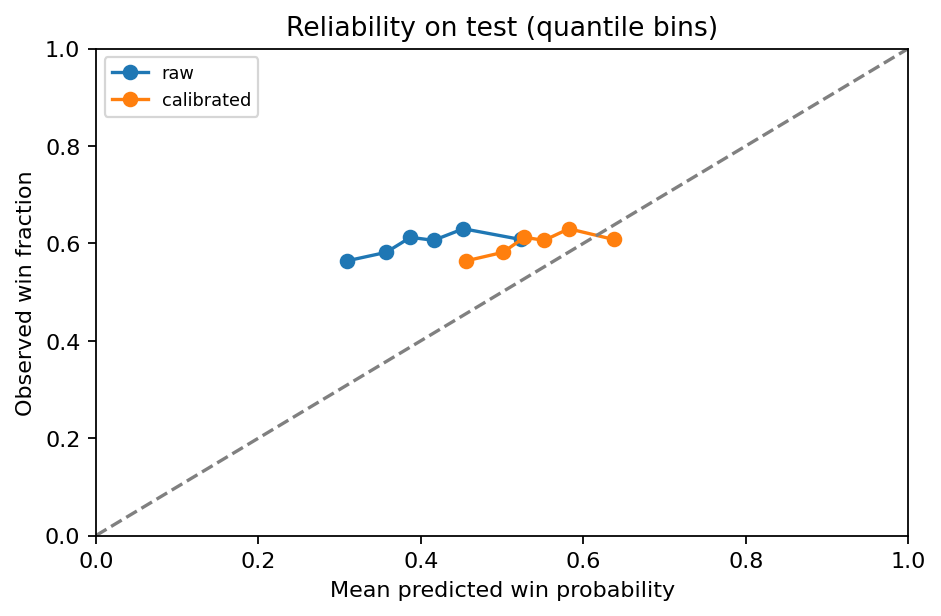

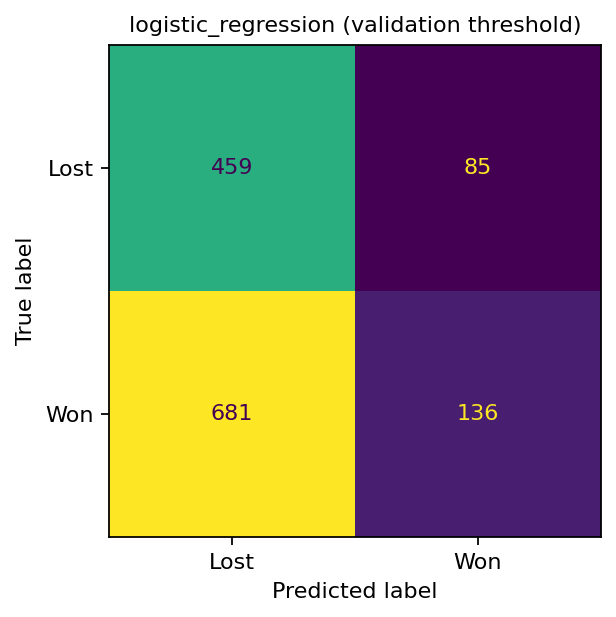

In [6]:
evaluate.make_figures(ev)
display(Image(filename=str(ev.out.figures / "roc_curves.png"), width=600))
display(Image(filename=str(ev.out.figures / "reliability.png"), width=500))
display(Image(filename=str(ev.out.figures / f"confusion_{ev.trained.selected}.png"), width=350))

## 4. Explanations

Permutation importance: ROC-AUC drop on test when one input is shuffled. TreeSHAP: raw Random Forest only.
Both describe the model's behaviour, not causes.

In [7]:
evaluate.explain_models(ev)
display(pd.read_csv(ev.out.explain / "permutation_importance_test.csv").head(10).round(4))
pd.read_csv(ev.out.explain / "rf_shap_global.csv").head(10).round(4)

/Users/thaiphan/sources/miu/cs582-project/.venv-crm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,mean_auc_drop,std_auc_drop
0,sales_agent,0.0228,0.0082
1,office_location,0.0085,0.0090
2,engage_month,0.0056,0.0013
3,engage_quarter,0.0041,0.0101
4,revenue,0.0031,0.0005
5,is_subsidiary,0.0023,0.0023
6,series,0.0021,0.0026
7,product,0.0018,0.0013
8,employees,0.0013,0.0004
9,regional_office,0.0002,0.0003


,feature,mean_absolute_shap
0,engage_quarter,0.0488
1,engage_month,0.0160
2,engage_dayofweek,0.0101
3,revenue_per_employee,0.0095
4,account_age_at_engage,0.0094
5,year_established,0.0093
6,employees,0.0066
7,engage_year,0.0064
8,revenue,0.0058
9,sales_price,0.0056


## 5. Audits

The close-value model is deliberately invalid: it shows how an outcome field fakes a near-perfect score.

In [8]:
evaluate.run_audits(ev)
display(pd.read_csv(ev.out.checks / "leakage_audit.csv")[["model", "roc_auc", "accuracy", "purpose"]].round(4))
pd.read_csv(ev.out.checks / "priority_test.csv").round(4)

,model,roc_auc,accuracy,purpose
0,logistic_regression,0.5238,0.4372,Pre-close feature set; no outcome predictors
1,LEAKY_close_value_stump,1.0000,1.0000,Invalid future information; illustration only


,priority,count,observed_win_rate,mean_probability
0,Low,5,0.2000,0.3893
1,Medium,1352,0.6021,0.5426
2,High,4,0.5000,0.7122


## 6. Novelty checks

Compares the as-of split with a no-purge and a random split, and checks that the explanations describe the model.

In [9]:
protocols, checks = evaluate.run_checks(ev)
display(protocols[["protocol", "model", "roc_auc_mean", "roc_auc_sd", "delta_vs_asof"]].round(4))
pd.json_normalize(checks, sep=".").T

Checking split protocols and explanations...

Early stopping occurred at epoch 41 with best_epoch = 29 and best_validation_auc = 0.51515


/Users/thaiphan/sources/miu/cs582-project/.venv-crm/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 13 with best_epoch = 1 and best_validation_auc = 0.51511


/Users/thaiphan/sources/miu/cs582-project/.venv-crm/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 15 with best_epoch = 3 and best_validation_auc = 0.55844


...

/Users/thaiphan/sources/miu/cs582-project/.venv-crm/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 45 with best_epoch = 33 and best_validation_auc = 0.56674


/Users/thaiphan/sources/miu/cs582-project/.venv-crm/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,protocol,model,roc_auc_mean,roc_auc_sd,delta_vs_asof
0,asof_purged,logistic_regression,0.5238,NaN,0.0000
1,asof_purged,random_forest,0.5180,NaN,0.0000
2,asof_purged,mlp,0.4954,NaN,0.0000
3,asof_purged,tabnet,0.5068,NaN,0.0000
4,chronological_no_purge,logistic_regression,0.5294,NaN,0.0056
5,chronological_no_purge,random_forest,0.5051,NaN,-0.0129
6,chronological_no_purge,mlp,0.4754,NaN,-0.0201
7,chronological_no_purge,tabnet,0.4779,NaN,-0.0289
8,random_stratified,logistic_regression,0.5456,0.0093,0.0218
9,random_stratified,random_forest,0.5335,0.0095,0.0155


,0
note,Checks whether explanations describe model beh...
agreement.model,random_forest_raw
agreement.rows,64
agreement.features,18
agreement.top_k,3
agreement.spearman_median,0.75707
agreement.spearman_mean,0.717987
agreement.top_overlap_mean,0.609375
agreement.top_overlap_random_expectation,0.166667
agreement.top_feature_same_sign_rate,1.0


## 7. Record the stage

In [10]:
manifest = evaluate.finish(ev)

EVALUATED: logistic_regression test ROC-AUC 0.5238


Next: `3_predict.ipynb`.